102 orientation files found
all orientations present
zero-byte files: none
keys : ['Reff', 'Rhalf', 'V_lum_den', 'binarea', 'image', 'lum_den', 'mags_V', 'rbins', 'sb_V']
shape: (1000, 1000) float32
range: 0.000 .. 843110.688  (masked/nan: 0)
Reff : 1.1417791417890735  Rhalf: 1.2917305668682488
vmin=0.000  vmax=106522.260


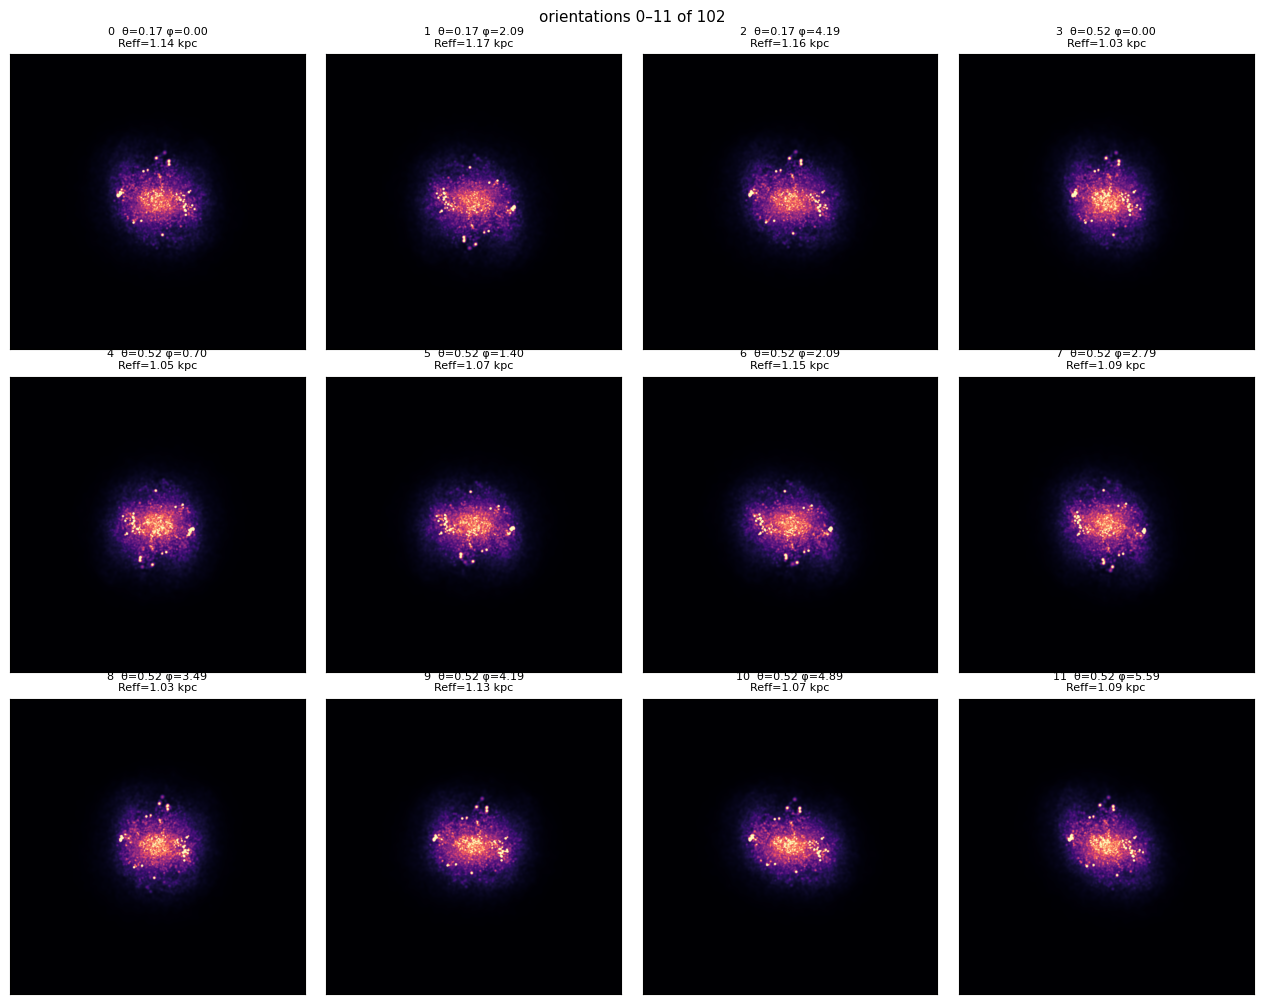

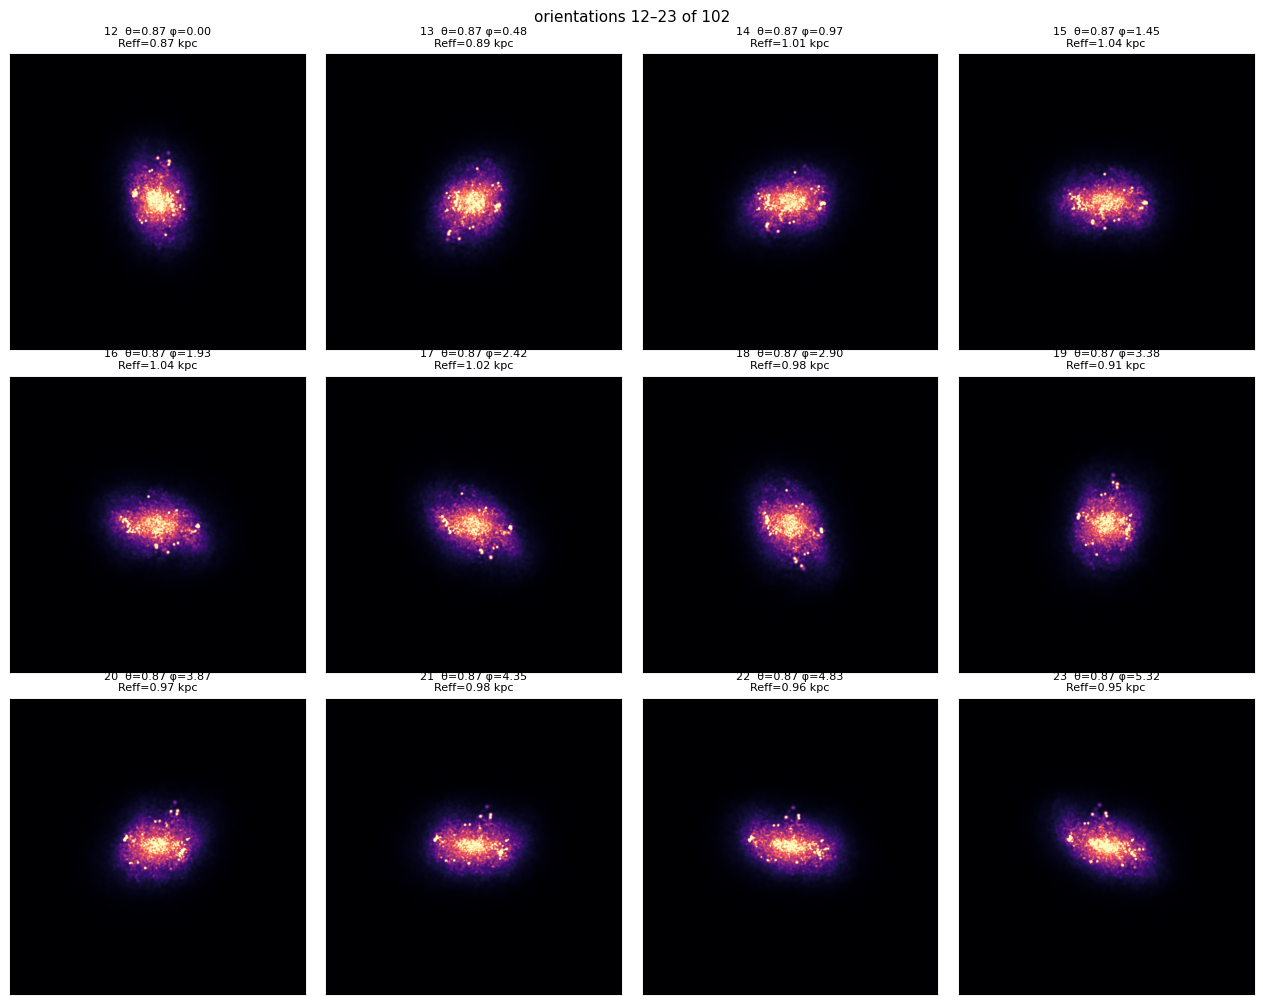

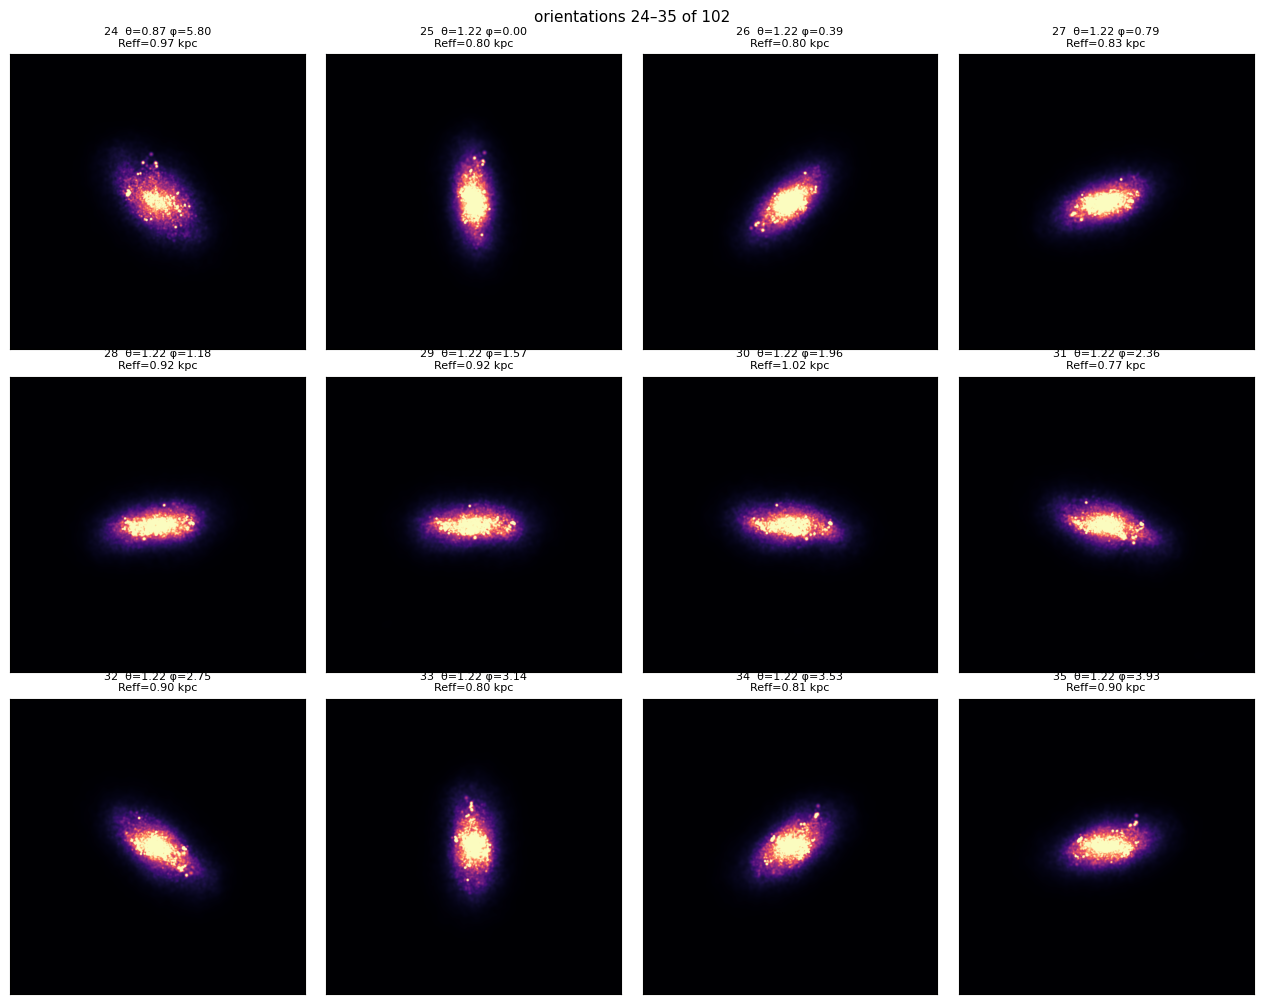

In [7]:
# # Inspect cached orientation images
#
# Pages through the per-orientation pickles written by `VBandStarImages`, a few at a time.
# Images are loaded lazily and LRU-cached, so nothing loads the full 100-orientation set at once.

import os
import re
import pickle
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt

# %matplotlib inline  # Jupyter magic — remove/ignore outside a notebook

FOLDER = ('/home/bk639/MCMC-deprojection/caches/'
          'vband_cache_cptmarvel.cosmo25cmb.4096g5HbwK1BH_n100/'
          'VBandStarImages_halo1')

N_GRID = 100   # how many orientations *should* be there

KEY_RE = re.compile(r'^(\d{4})_t([+-][\d.]+)_p([+-][\d.]+)\.pkl$')

entries = []
for fname in os.listdir(FOLDER):
    m = KEY_RE.match(fname)
    if m:
        entries.append((int(m.group(1)), float(m.group(2)), float(m.group(3)), fname))
entries.sort()

print(f'{len(entries)} orientation files found')

# ## Completeness check
#
# Any index in `0..N_GRID-1` without a file is an orientation whose worker died,
# or one that was never reached.

present = {e[0] for e in entries}
missing = sorted(set(range(N_GRID)) - present)

if missing:
    print(f'MISSING {len(missing)} orientations: {missing}')
else:
    print('all orientations present')

# Also flag zero-byte or unreadable files (interrupted writes shouldn't
# happen given os.replace, but cheap to verify).
bad = [f for *_, f in entries if os.path.getsize(os.path.join(FOLDER, f)) == 0]
print('zero-byte files:', bad or 'none')

@lru_cache(maxsize=24)
def load(fname):
    with open(os.path.join(FOLDER, fname), 'rb') as fh:
        return pickle.load(fh)


# Peek at one to see what's stored and what the value range looks like.
d = load(entries[0][3])
img = np.ma.masked_invalid(d['image'])

print('keys :', sorted(d.keys()))
print('shape:', img.shape, img.dtype)
print('range: {:.3f} .. {:.3f}  (masked/nan: {})'.format(
    img.min(), img.max(), int(np.ma.count_masked(img))))
print('Reff :', d['Reff'], ' Rhalf:', d['Rhalf'])

# ## Shared colour scale
#
# Fixing `vmin`/`vmax` across every panel is what makes the scan useful — with per-panel
# autoscaling, a projection that failed and produced near-empty output still looks like a
# normal galaxy. Percentiles are taken from a subsample of orientations.

sample_idx = np.linspace(0, len(entries) - 1, 8).astype(int)
vals = []
for i in sample_idx:
    a = np.ma.masked_invalid(load(entries[i][3])['image']).compressed()
    vals.append(a)
vals = np.concatenate(vals)

VMIN, VMAX = np.percentile(vals, [5, 99.5])
print(f'vmin={VMIN:.3f}  vmax={VMAX:.3f}')
del vals

def show_page(start=0, n=12, ncols=4, cmap='magma'):
    """Plot orientations [start, start+n) in a grid."""
    page = entries[start:start + n]
    if not page:
        print('past the end')
        return

    nrows = int(np.ceil(len(page) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (idx, theta, phi, fname) in zip(axes, page):
        d = load(fname)
        img = np.ma.masked_invalid(d['image'])
        ax.imshow(img, origin='lower', cmap=cmap, vmin=VMIN, vmax=VMAX)
        ax.set_title(f'{idx}  θ={theta:.2f} φ={phi:.2f}\nReff={d["Reff"]:.2f} kpc',
                     fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

    for ax in axes[len(page):]:
        ax.axis('off')

    fig.suptitle(f'orientations {start}–{start + len(page) - 1} of {len(entries)}',
                 fontsize=11)
    fig.tight_layout()
    plt.show()


show_page(0)

show_page(12)

show_page(24)

# ## Interactive scan
#
# Needs `ipywidgets`. Drag to page through; the LRU cache keeps recent pages warm.


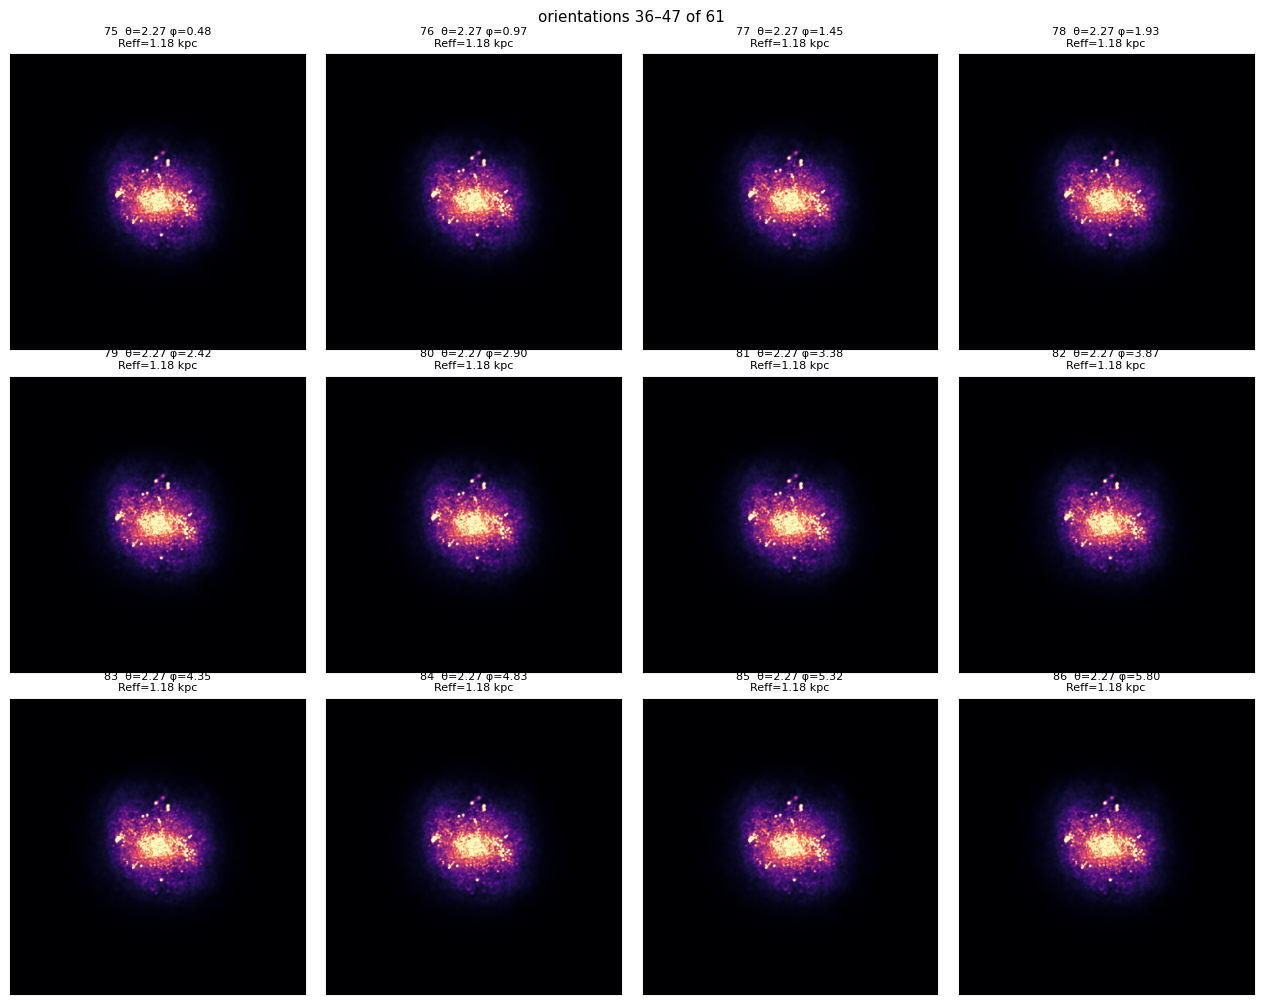

In [5]:
show_page(36)